In [1]:
import torch
import torch.nn as nn
from src.dataset import create_dataloaders
from src.model import MultiAttentionNet
from src.loss import RegionalIndependenceLoss
from src.agda import AGDA
from src.trainer import Trainer
from src.utils import ExperimentJSONLogger
from src.evaluate import load_model_weights, plot_training_results, run_full_evaluation, visualize_test_attention

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. MINIMAL CONFIGURATION FOR SANITY CHECK ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
exp_name = "sanity_check_test3"

config = {
    "model_name": "efficientnet_b0", # Lightweight for testing
    "M_attentions": 2,               # Minimal heads
    "dropout_rate": 0.5,
    "learning_rate": 1e-4,
    "batch_size": 4,                 # Tiny batch
    "num_epochs": 6,                 # Only 2 epochs to see the save/log process
    "frames_per_video": 6,           # Only 2 frames per folder
    "max_videos": 8,                 # ONLY 4 videos total (very fast)
    "agda_prob": 1.0,                # Force AGDA to test if it works
    "ril_alpha": 0.05,
    "ril_margin": 0.2
}

print(f"Running Sanity Check on: {DEVICE}")



Running Sanity Check on: cuda


In [3]:
# --- 2. PIPELINE EXECUTION ---

# A. Data (Check if dataset.py works)
dataloaders, sizes = create_dataloaders(
    root_dir="data/Forensics++/",
    batch_size=config["batch_size"],
    frames_per_video=config["frames_per_video"],
    max_videos=config["max_videos"]
)

# B. Model & Components (Check model.py, loss.py, agda.py)
model = MultiAttentionNet(
    model_name=config["model_name"],
    M=config["M_attentions"],
    dropout_rate=config["dropout_rate"]
)

criterion_ce = nn.CrossEntropyLoss()

criterion_ril = RegionalIndependenceLoss(
    M=config["M_attentions"], 
    num_features_d=model.feat_dim_texture, m_out=0.2, m_in_real=0.05, m_in_fake=0.1 # Utilise le 24 du modèle
).to(DEVICE)
agda = AGDA(p=config["agda_prob"])
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])




Phase 'train': 12 vidéos (6R/6F), 72 images.
Phase 'val': 2 vidéos (1R/1F), 12 images.
Phase 'test': 2 vidéos (1R/1F), 12 images.


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [4]:
# C. Logging & Paths (Check utils.py)
log_path = f"logs/{exp_name}.json"
model_path = f"models/{exp_name}.pth"
logger = ExperimentJSONLogger(filepath=log_path, config=config)

In [5]:

# D. Training (Check trainer.py)
trainer = Trainer(
    model=model,
    dataloaders=dataloaders,
    criterion_ce=criterion_ce,
    criterion_ril=criterion_ril,
    optimizer=optimizer,
    agda=agda,
    device=DEVICE
)

# This should run in less than 1 minute
history = trainer.fit(
    num_epochs=config["num_epochs"],
    model_save_path=model_path,
    log_callback=logger.log_epoch
)



Epoch 1/6 | Time: 5.949808120727539s | Train Loss: 31.798520459069145 AUC: 0.6103395061728395 | Val Loss: 40.592095057169594 AUC: 0.08333333333333333 <- Best model saved
Metrics saved to logs/sanity_check_test3.json
Epoch 2/6 | Time: 5.146899700164795s | Train Loss: 10.510061555438572 AUC: 0.9305555555555555 | Val Loss: 32.551326751708984 AUC: 0.0
Metrics saved to logs/sanity_check_test3.json
Epoch 3/6 | Time: 5.158901214599609s | Train Loss: 6.688815911610921 AUC: 0.8773148148148148 | Val Loss: 22.072283426920574 AUC: 0.0
Metrics saved to logs/sanity_check_test3.json
Epoch 4/6 | Time: 5.152072191238403s | Train Loss: 4.696171138021681 AUC: 0.9405864197530864 | Val Loss: 20.005401611328125 AUC: 0.0
Metrics saved to logs/sanity_check_test3.json
Epoch 5/6 | Time: 5.153717994689941s | Train Loss: 3.783319718307919 AUC: 0.9282407407407408 | Val Loss: 17.10509745279948 AUC: 0.0
Metrics saved to logs/sanity_check_test3.json
Epoch 6/6 | Time: 5.206879138946533s | Train Loss: 2.894161025683085

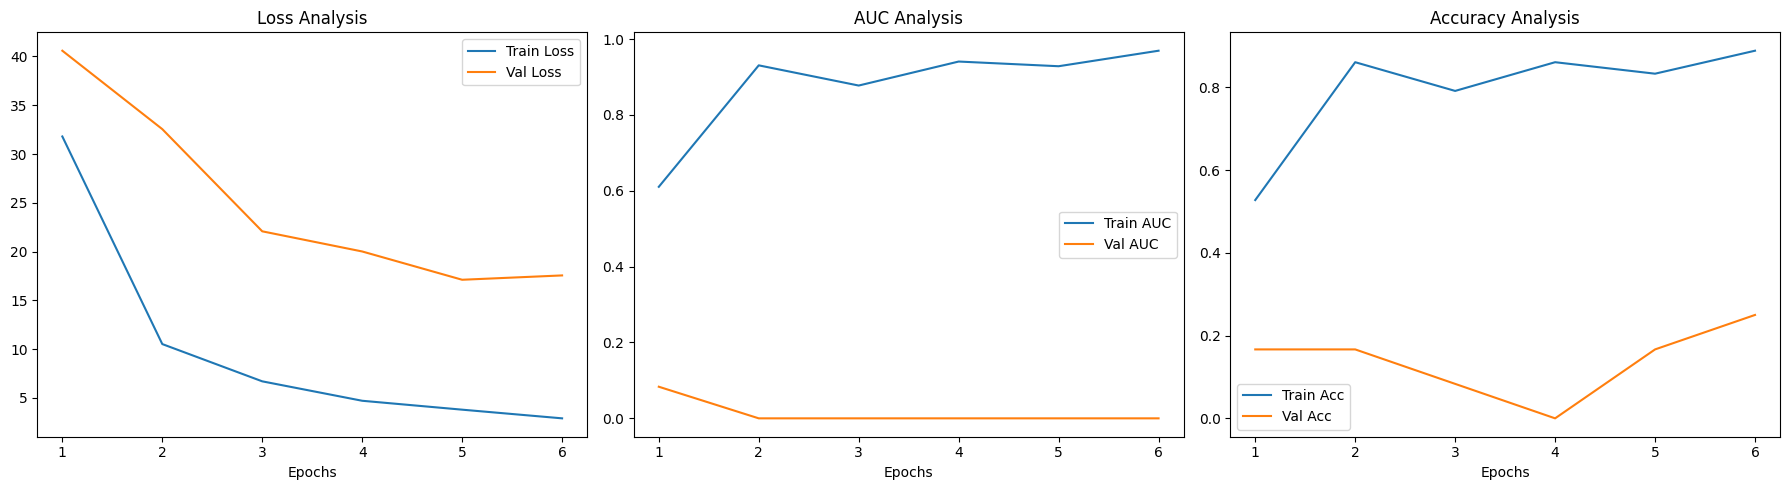


--- TEST SET PERFORMANCE ---
Test Accuracy : 0.5833333333333334
Test AUC      : 1.0


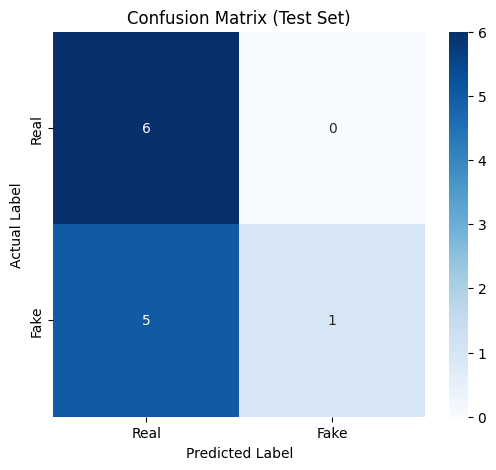

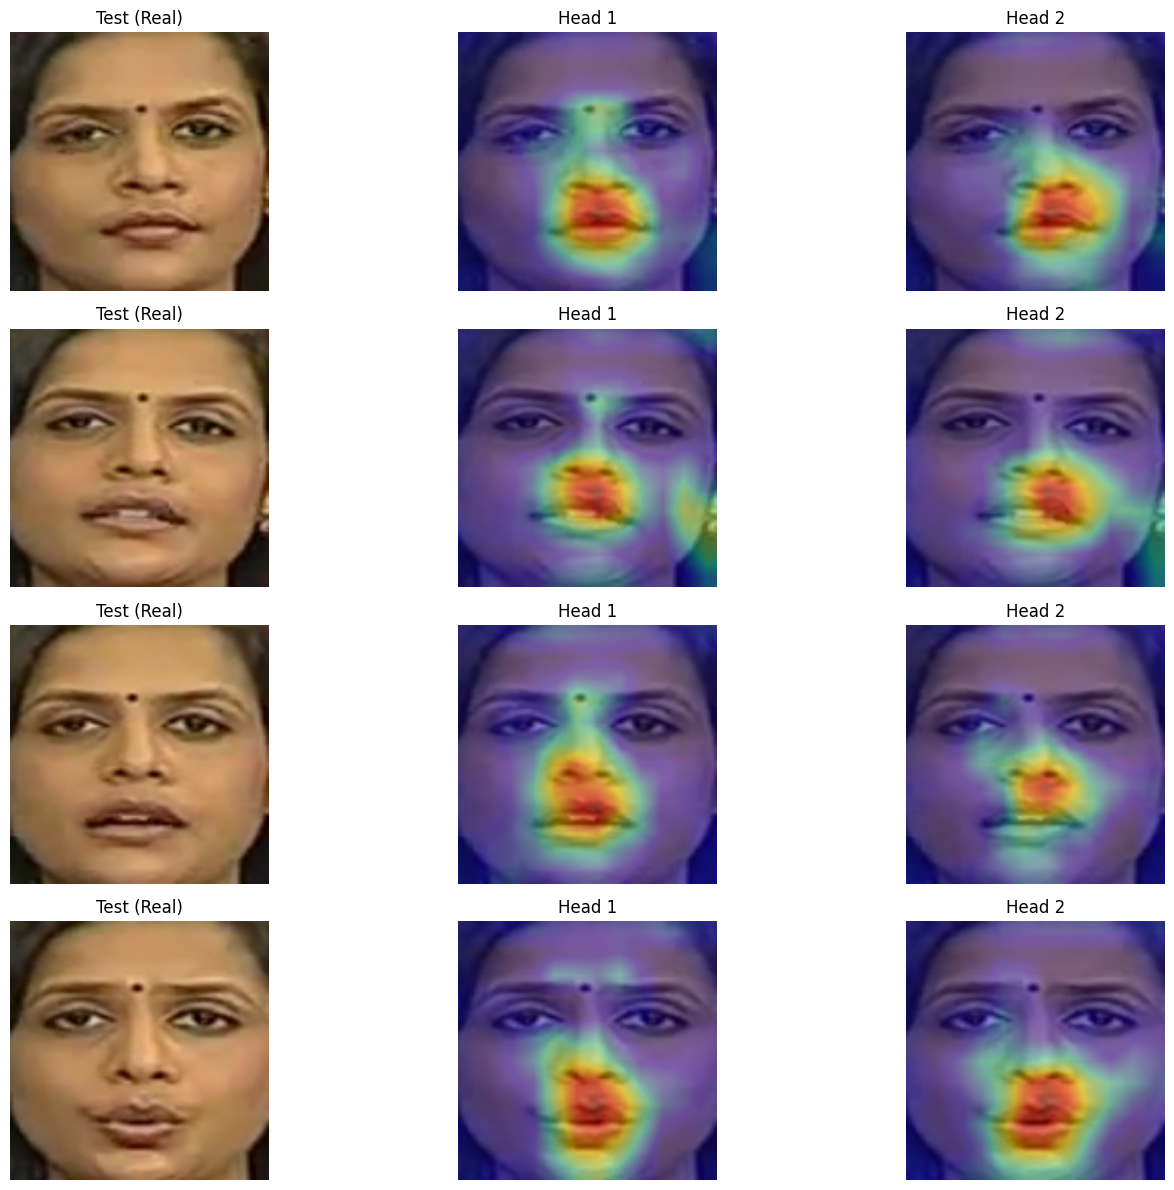

In [6]:

log_path = "logs/sanity_check_test3.json"  # Remplace par le nom exact de ton fichier
model_path = "models/sanity_check_test3.pth"
# 1. Courbes de Training
plot_training_results(log_path)

# 2. Charger le meilleur modèle (on passe l'objet model déjà créé)
test_model = load_model_weights(model, model_path, DEVICE)

# 3. Évaluation Rigoureuse + Matrice de Confusion
test_acc, test_auc = run_full_evaluation(test_model, dataloaders['test'], DEVICE)

# 4. Visualisation Attention
visualize_test_attention(test_model, dataloaders['test'], DEVICE)


--- Verifying Visuals & Loading ---


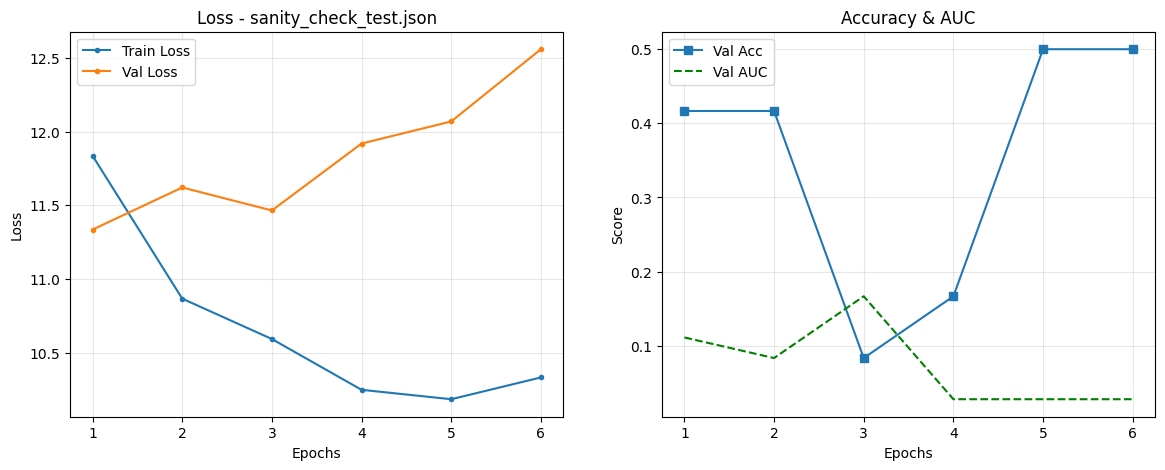

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Loaded weights: sanity_check_test.pth


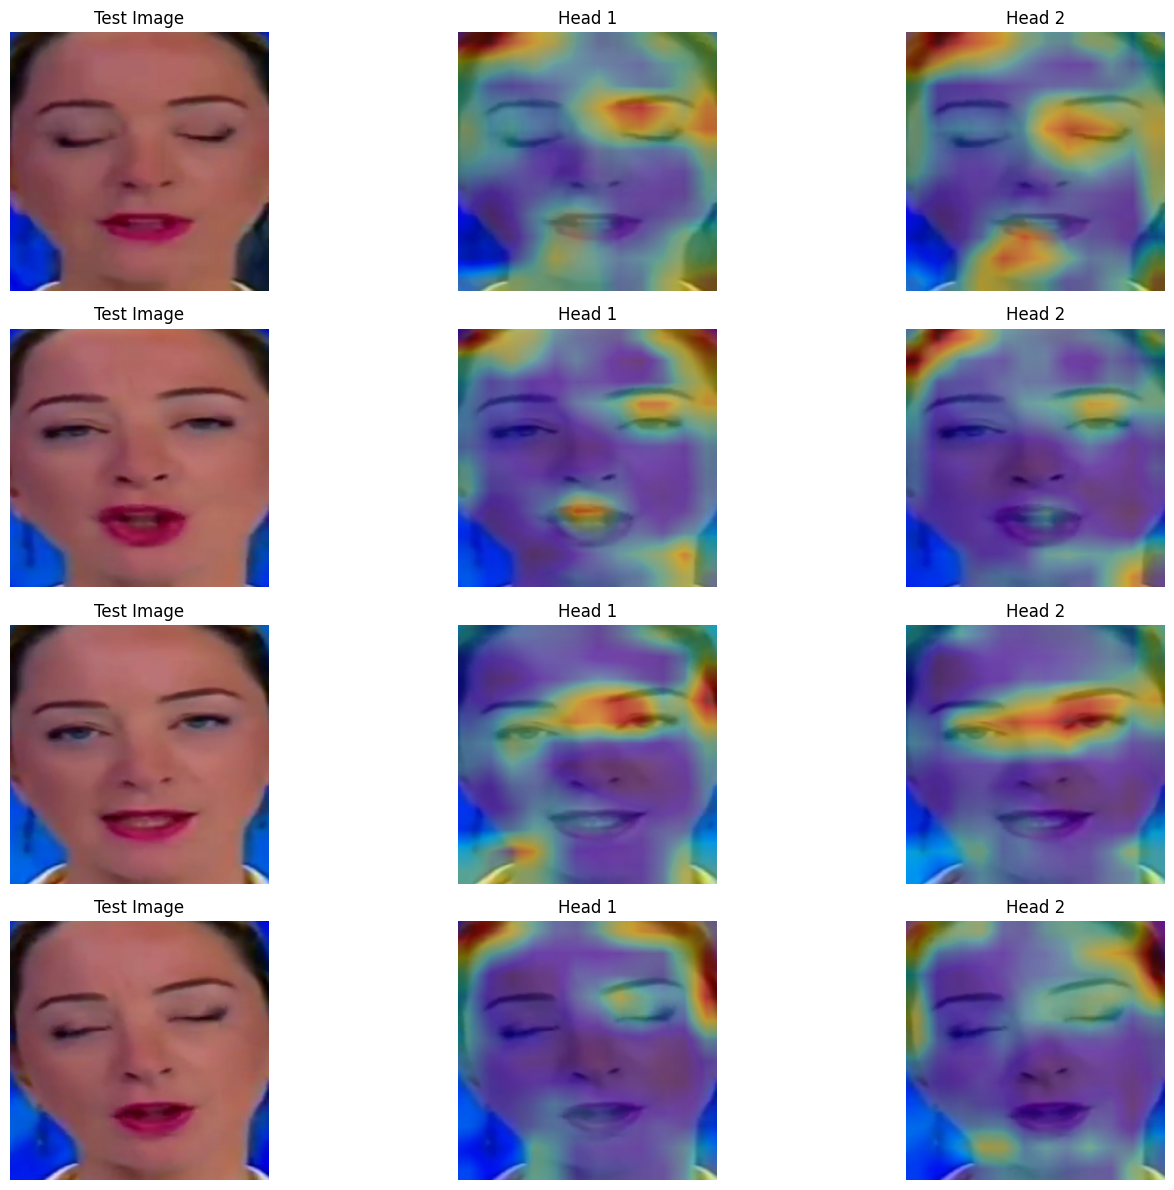


✅ SANITY CHECK COMPLETE: The whole pipeline is working!


In [5]:
# --- 3. FINAL VERIFICATION (Check visualize.py) ---
print("\n--- Verifying Visuals & Loading ---")
plot_training_results(log_path)
test_model = load_model_weights(model_path, m_heads=config["M_attentions"], device=DEVICE)
visualize_test_attention(test_model, dataloaders['val'], device=DEVICE)

print("\n✅ SANITY CHECK COMPLETE: The whole pipeline is working!")

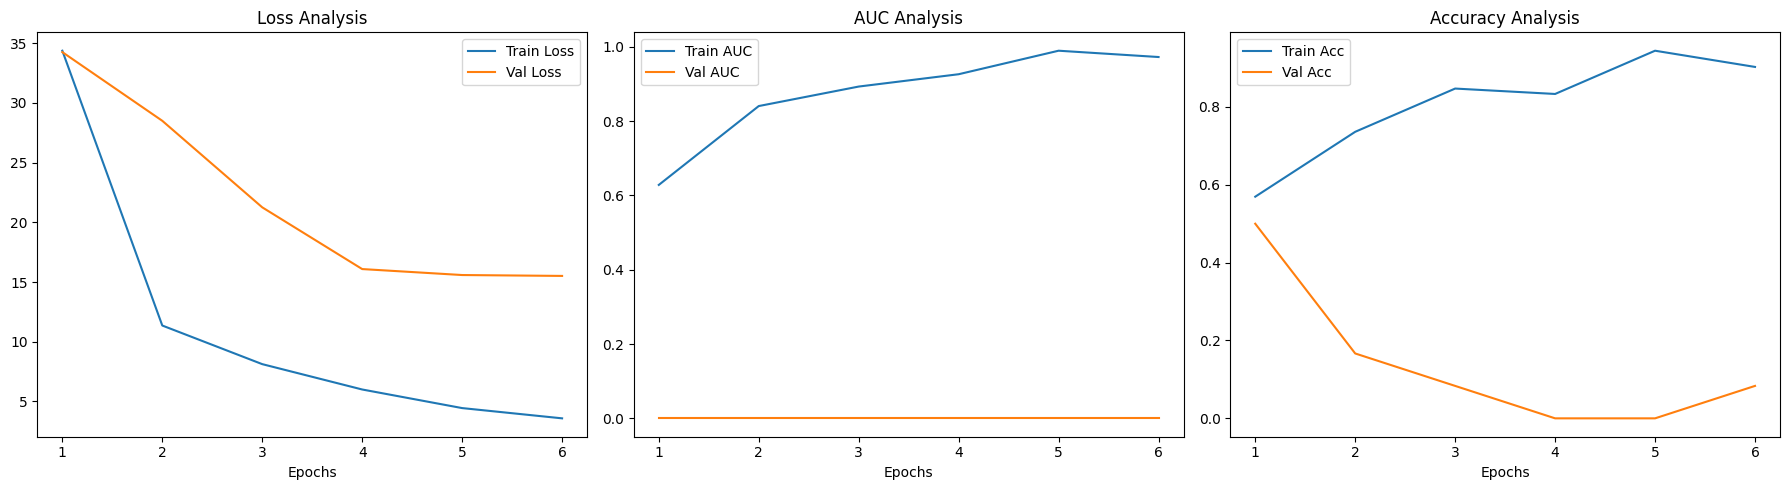

FileNotFoundError: [Errno 2] No such file or directory: 'models/sanity_check_test3.pth'

In [6]:

log_path = "logs/sanity_check_test3.json"  # Remplace par le nom exact de ton fichier
model_path = "models/sanity_check_test3.pth"
# 1. Courbes de Training
plot_training_results(log_path)

# 2. Charger le meilleur modèle (on passe l'objet model déjà créé)
test_model = load_model_weights(model, model_path, DEVICE)

# 3. Évaluation Rigoureuse + Matrice de Confusion
test_acc, test_auc = run_full_evaluation(test_model, dataloaders['test'], DEVICE)

# 4. Visualisation Attention
visualize_test_attention(test_model, dataloaders['test'], DEVICE)

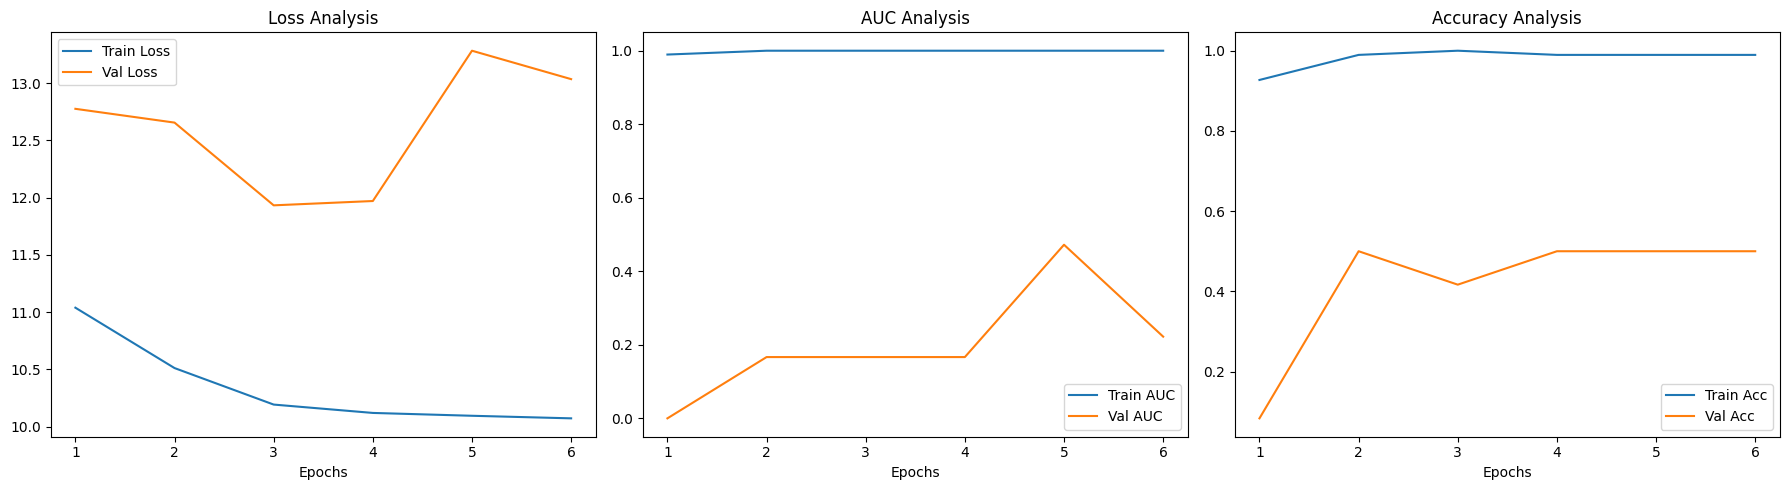


--- TEST SET PERFORMANCE ---
Test Accuracy : 1.0
Test AUC      : 1.0


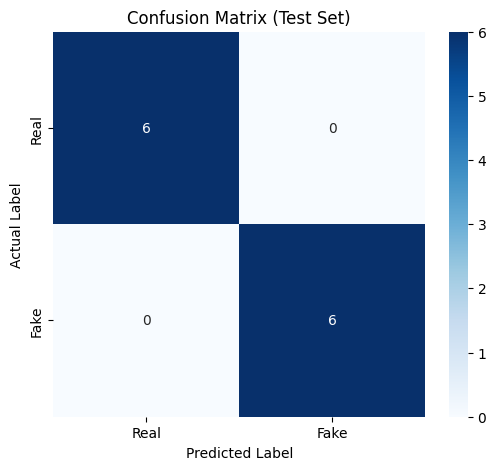

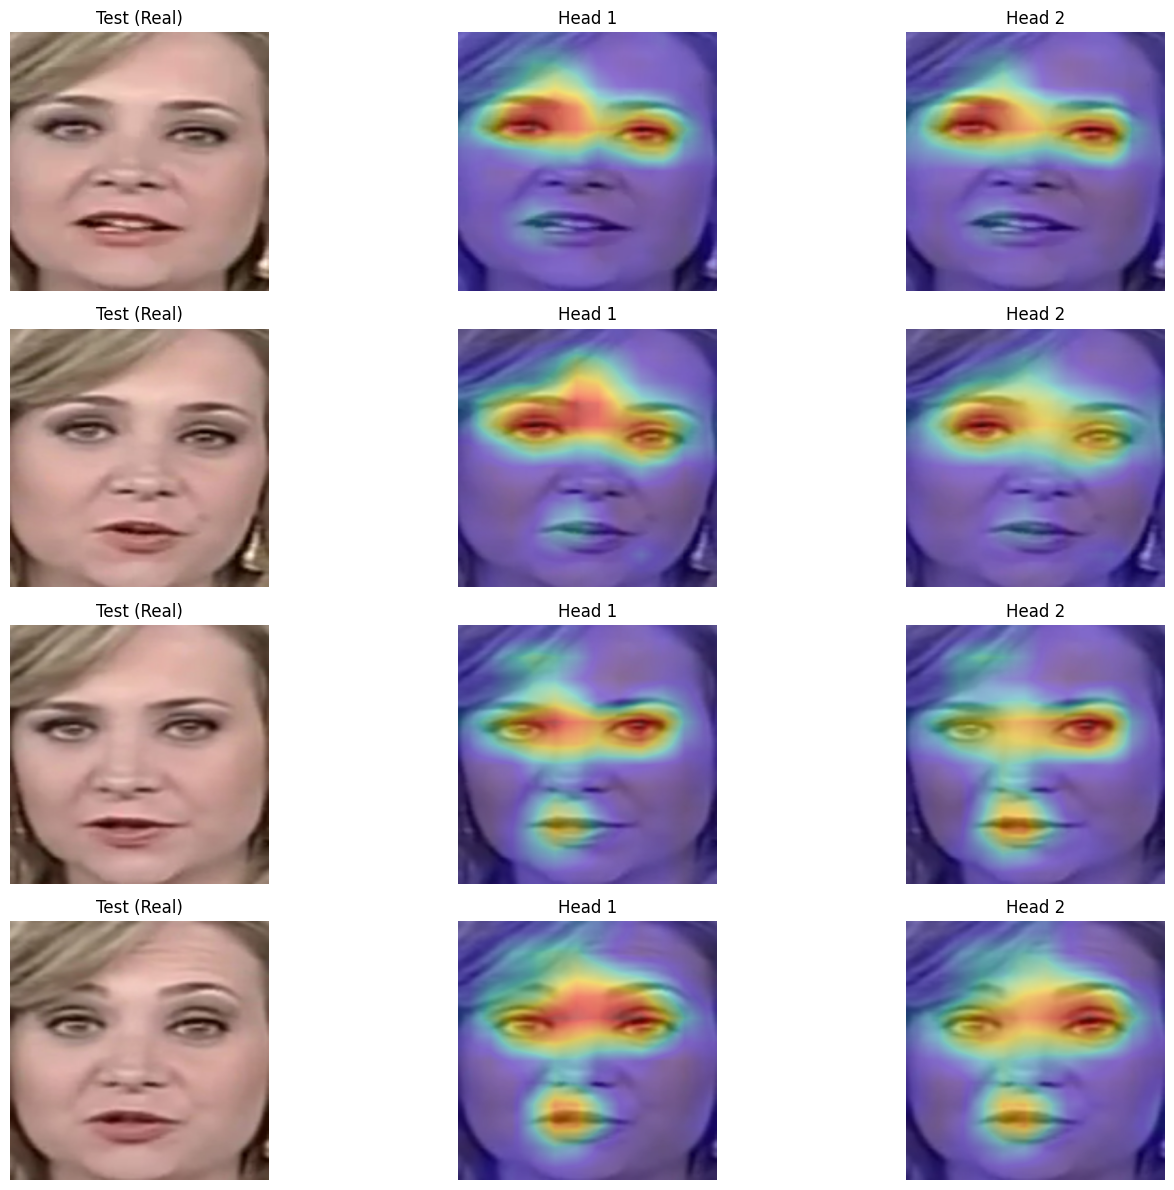

In [4]:

log_path = "logs/sanity_check_test.json"  # Remplace par le nom exact de ton fichier
model_path = "models/sanity_check_test.pth"
# 1. Courbes de Training
plot_training_results(log_path)

# 2. Charger le meilleur modèle (on passe l'objet model déjà créé)
test_model = load_model_weights(model, model_path, DEVICE)

# 3. Évaluation Rigoureuse + Matrice de Confusion
test_acc, test_auc = run_full_evaluation(test_model, dataloaders['test'], DEVICE)

# 4. Visualisation Attention
visualize_test_attention(test_model, dataloaders['test'], DEVICE)